# Asymmetry, Example 1: a classical Z4 symmetry

**Manuscript map.** Sec. III D, Fig. 5, Eqs. (54)-(58).

A four-state continuous-time Markov chain lives on a ring. Its generator
is covariant under the cyclic shift $n\mapsto n+1\pmod 4$, so each
Fourier mode belongs to a single irreducible representation of
$\mathbb Z_4$.

We compare a weakly asymmetric distribution supported in the slow
$\mu=1,3$ sectors with a more asymmetric distribution supported only in
the fast $\mu=2$ sector. This is the smallest fully classical symmetry
Mpemba example in the paper.


In [14]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_HERE = Path.cwd().resolve()
for _candidate in [_HERE, *_HERE.parents]:
    if (_candidate / "tools" / "notebook_utils.py").exists():
        _TOOLS_DIR = _candidate / "tools"
        break
else:
    raise RuntimeError(
        "Could not locate tools/notebook_utils.py from cwd or its parents."
    )
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. Generator and Fourier modes

With chirality $\varepsilon$, Eq. (54) has eigenvalues

$$
\lambda_0=0,\qquad
\lambda_{1,3}=-2\pm 2i\varepsilon,\qquad
\lambda_2=-4.
$$

The $\mu=2$ component therefore decays twice as fast in amplitude as the
$\mu=1,3$ pair.


In [15]:
EPSILON = 0.25
L = np.array([
    [-2, 1 + EPSILON, 0, 1 - EPSILON],
    [1 - EPSILON, -2, 1 + EPSILON, 0],
    [0, 1 - EPSILON, -2, 1 + EPSILON],
    [1 + EPSILON, 0, 1 - EPSILON, -2],
], dtype=float)

phase = np.exp(2j * np.pi / 4)
fourier_modes = {
    mu: np.array([phase ** (mu * n) for n in range(4)]) / 2
    for mu in range(4)
}
eigenvalues = {
    0: 0,
    1: -2 + 2j * EPSILON,
    2: -4,
    3: -2 - 2j * EPSILON,
}

for mu in range(4):
    assert np.allclose(
        L @ fourier_modes[mu],
        eigenvalues[mu] * fourier_modes[mu],
    )
assert np.allclose(L.sum(axis=0), 0)


## 2. Initial distributions and asymmetry monotone

Following the panel labels of Fig. 5,

$$
\mathbf p_1=\tfrac12\mathbf r_0+\tfrac12\mathbf r_2,
\qquad
\mathbf p_2=\tfrac12\mathbf r_0
+\tfrac14\mathbf r_1+\tfrac14\mathbf r_3.
$$

Here $\mathbf p_1=(1/2,0,1/2,0)$ is the initially more asymmetric
fast-sector state and $\mathbf p_2=(1/2,1/4,0,1/4)$ is the slow-sector
state, matching Fig. 5(b,c) of the paper. (The paper's Eq. (58) uses the
opposite labeling; we follow the figure's convention.) The group twirl
sends every distribution to the uniform vector, so

$$
M[\mathbf p]=D(\mathbf p\Vert\mathcal G\mathbf p)
=\sum_n p_n\log(4p_n).

$$

In [16]:
p_1 = (
    fourier_modes[0] / 2
    + fourier_modes[2] / 2
).real
p_2 = (
    fourier_modes[0] / 2
    + fourier_modes[1] / 4
    + fourier_modes[3] / 4
).real
uniform = np.full(4, 0.25)

def asymmetry(probability):
    return nu.classical_relative_entropy(probability, uniform)

for probability in (p_1, p_2):
    assert np.isclose(probability.sum(), 1)
    assert np.all(probability >= 0)

print("p_1 (fast sector): ", p_1)
print("p_2 (slow sectors):", p_2)
print("Initial asymmetries:", asymmetry(p_1), asymmetry(p_2))


p_1 (fast sector):  [0.5 0.  0.5 0. ]
p_2 (slow sectors): [0.5  0.25 0.   0.25]
Initial asymmetries: 0.6931471805599453 0.3465735902799727


## 3. Dynamics and Mpemba crossing

The relative entropy is quadratic close to the symmetric state. With
the Fig. 5 labeling, the asymptotic decays predicted by the mode
spectrum are

$$
M[\mathbf p_1(t)]\sim\tfrac12e^{-8t},
\qquad
M[\mathbf p_2(t)]\sim\tfrac14e^{-4t}.
$$


In [17]:
times = np.linspace(0, 2, 600)
evolution_1 = np.array([la.expm(L * t) @ p_1 for t in times])
evolution_2 = np.array([la.expm(L * t) @ p_2 for t in times])
M_1 = np.array([asymmetry(p) for p in evolution_1])
M_2 = np.array([asymmetry(p) for p in evolution_2])
tau = nu.crossing_time(times, M_1, M_2)

print(f"Crossing time: {tau:.4f}")
assert M_1[0] > M_2[0]
assert np.isfinite(tau)


Crossing time: 0.1594


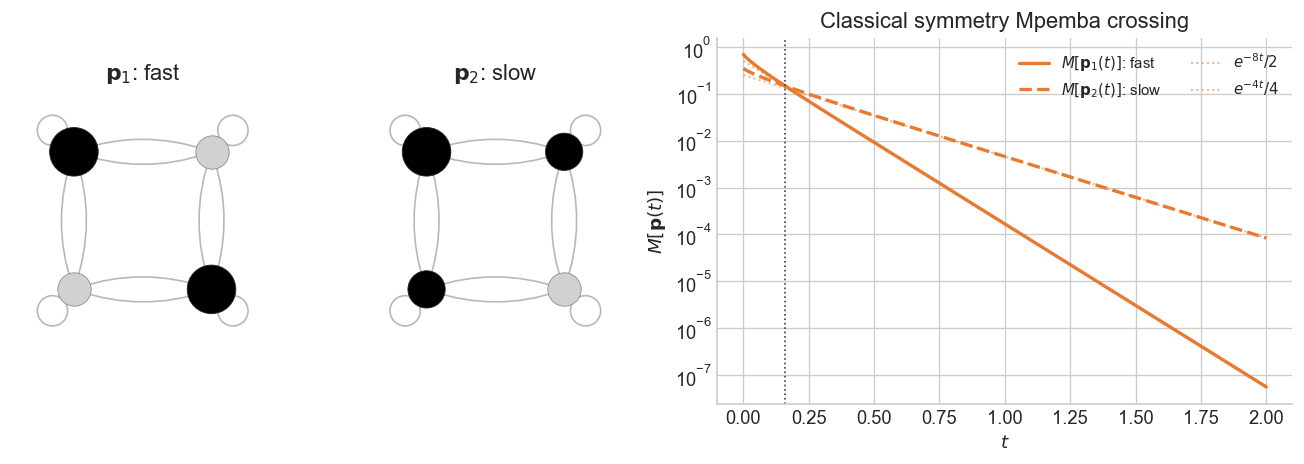

In [21]:
positions = np.array([[0, 1], [1, 1], [1, 0], [0, 0]])
fig = plt.figure(figsize=(11, 4))
grid = fig.add_gridspec(1, 3, width_ratios=[1, 1, 2.2])

ARROW_GRAY = "0.72"
PLACEHOLDER_GRAY = "0.82"

def draw_ring(ax, probability):
    center = positions.mean(axis=0)
    # Two directed arrows per neighboring pair (rad>0 -> CW curves outward,
    # CCW curves inward automatically because the traversal direction flips).
    for site in range(4):
        p_from = positions[site]
        p_to = positions[(site + 1) % 4]
        for xy, xytext in ((p_to, p_from), (p_from, p_to)):
            ax.annotate(
                "", xy=xy, xytext=xytext,
                arrowprops=dict(
                    arrowstyle="-|>",
                    connectionstyle="arc3,rad=0.18",
                    color=ARROW_GRAY, lw=1,
                ),
                zorder=1,
            )
    # Self-loops (L_{nn}) at each corner, offset outward from the ring center.
    for p_i in positions:
        direction = p_i - center
        direction = direction / np.linalg.norm(direction)
        loop_center = p_i + 0.22 * direction
        loop = plt.matplotlib.patches.Ellipse(
            loop_center, width=0.22, height=0.22,
            fill=False, edgecolor=ARROW_GRAY, linewidth=1, zorder=1,
        )
        ax.add_patch(loop)
    # Light-gray placeholder for every site, then black overlay proportional
    # to the probability (so p=0 shows just the placeholder).
    ax.scatter(
        positions[:, 0], positions[:, 1],
        s=400, c=PLACEHOLDER_GRAY,
        edgecolor="0.55", lw=0.5, zorder=2,
    )
    filled = probability > 1e-6
    if filled.any():
        ax.scatter(
            positions[filled, 0], positions[filled, 1],
            s=150 + 1400 * probability[filled],
            c="black", edgecolor="0.15", lw=0.5, zorder=3,
        )

panels = [
    (p_1, r"$\mathbf{p}_1$: fast"),
    (p_2, r"$\mathbf{p}_2$: slow"),
]
for index, (probability, title) in enumerate(panels):
    ax = fig.add_subplot(grid[0, index])
    draw_ring(ax, probability)
    ax.set(aspect="equal", title=title, xlim=(-0.45, 1.45), ylim=(-0.45, 1.45))
    ax.axis("off")

ax = fig.add_subplot(grid[0, 2])
ax.semilogy(times, M_1, color=ORANGE, lw=2, ls="-",
            label=r"$M[\mathbf{p}_1(t)]$: fast")
ax.semilogy(times, M_2, color=ORANGE, lw=2, ls="--",
            label=r"$M[\mathbf{p}_2(t)]$: slow")
ax.semilogy(times, 0.5 * np.exp(-8 * times), color=ORANGE,
            ls=":", lw=1.2, alpha=0.55, label=r"$e^{-8t}/2$")
ax.semilogy(times, 0.25 * np.exp(-4 * times), color=ORANGE,
            ls=":", lw=1.2, alpha=0.55, label=r"$e^{-4t}/4$")
ax.axvline(tau, color="0.25", ls=":", lw=1)
ax.set(xlabel=r"$t$", ylabel=r"$M[\mathbf{p}(t)]$",
       title="Classical symmetry Mpemba crossing")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


## Takeaway

Chirality produces oscillatory phases in the $\mu=1,3$ pair, but their
real decay rate remains $-2$. The more asymmetric $\mu=2$ state avoids
those slow symmetry-restoring sectors and loses its resource at twice the
amplitude rate, creating the crossing.
